# Lab | Pandas

In this lab, we will be working with the customer data from an insurance company, which can be found in the CSV file located at the following link: https://raw.githubusercontent.com/data-bootcamp-v4/data/main/file1.csv

The data includes information such as customer ID, state, gender, education, income, and other variables that can be used to perform various analyses.

Throughout the lab, we will be using the pandas library in Python to manipulate and analyze the data. Pandas is a powerful library that provides various data manipulation and analysis tools, including the ability to load and manipulate data from a variety of sources, including CSV files.

# Import all the libraries here

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data

In [2]:
data = pd.read_csv("customer_data.csv")

df = data.copy()

In [3]:
df

,Customer,ST,GENDER,Education,Customer Lifetime Value,Income,Monthly Premium Auto,Number of Open Complaints,Policy Type,Vehicle Class,Total Claim Amount
0,RB50392,Washington,NaN,Master,NaN,0.0,1000.0,1/0/00,Personal Auto,Four-Door Car,2.704934
1,QZ44356,Arizona,F,Bachelor,697953.59%,0.0,94.0,1/0/00,Personal Auto,Four-Door Car,1131.464935
2,AI49188,Nevada,F,Bachelor,1288743.17%,48767.0,108.0,1/0/00,Personal Auto,Two-Door Car,566.472247
3,WW63253,California,M,Bachelor,764586.18%,0.0,106.0,1/0/00,Corporate Auto,SUV,529.881344
4,GA49547,Washington,M,High School or Below,536307.65%,36357.0,68.0,1/0/00,Personal Auto,Four-Door Car,17.269323
...,...,...,...,...,...,...,...,...,...,...,...
4003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Description

- Customer - Customer ID

- ST - State where customers live

- Gender - Gender of the customer

- Education - Background education of customers 

- Customer Lifetime Value - Customer lifetime value(CLV) is the total revenue the client will derive from their entire relationship with a customer. In other words, is the predicted or calculated value of a customer over their entire duration as a policyholder with the insurance company. It is an estimation of the net profit that the insurance company expects to generate from a customer throughout their relationship with the company. Customer Lifetime Value takes into account factors such as the duration of the customer's policy, premium payments, claim history, renewal likelihood, and potential additional services or products the customer may purchase. It helps insurers assess the long-term profitability and value associated with retaining a particular customer.

- Income - Customers income

- Monthly Premium Auto - Amount of money the customer pays on a monthly basis as a premium for their auto insurance coverage. It represents the recurring cost that the insured person must pay to maintain their insurance policy and receive coverage for potential damages, accidents, or other covered events related to their vehicle.

- Number of Open Complaints - Number of complaints the customer opened

- Policy Type - There are three type of policies in car insurance (Corporate Auto, Personal Auto, and Special Auto)

- Vehicle Class - Type of vehicle classes that customers have Two-Door Car, Four-Door Car SUV, Luxury SUV, Sports Car, and Luxury Car

- Total Claim Amount - the sum of all claims made by the customer. It represents the total monetary value of all approved claims for incidents such as accidents, theft, vandalism, or other covered events.


External Resources: https://towardsdatascience.com/filtering-data-frames-in-pandas-b570b1f834b9

## Challenge 1: Understanding the data

In this challenge, you will use pandas to explore a given dataset. Your task is to gain a deep understanding of the data by analyzing its characteristics, dimensions, and statistical properties.

- Identify the dimensions of the dataset by determining the number of rows and columns it contains.
- Determine the data types of each column and evaluate whether they are appropriate for the nature of the variable. You should also provide suggestions for fixing any incorrect data types.
- Identify the number of unique values for each column and determine which columns appear to be categorical. You should also describe the unique values of each categorical column and the range of values for numerical columns, and give your insights.
- Compute summary statistics such as mean, median, mode, standard deviation, and quartiles to understand the central tendency and distribution of the data for numerical columns. You should also provide your conclusions based on these summary statistics.
- Compute summary statistics for categorical columns and providing your conclusions based on these statistics.

In [4]:
# dimension
df.shape

(4008, 11)

In [5]:
# data types of the columns
df.dtypes

Customer                      object
ST                            object
GENDER                        object
Education                     object
Customer Lifetime Value       object
Income                       float64
Monthly Premium Auto         float64
Number of Open Complaints     object
Policy Type                   object
Vehicle Class                 object
Total Claim Amount           float64
dtype: object

**Comments**
- `Customer Lifetime Value` should be a `float` without the % at the end of each value. This needs to be fixed.
- `Number of Open Complaints` should be `int` without the `\` formatting. This also needs to be fixed.

In [6]:
# number of unique values
df.nunique()

Customer                     1071
ST                              8
GENDER                          5
Education                       6
Customer Lifetime Value      1027
Income                        774
Monthly Premium Auto          132
Number of Open Complaints       6
Policy Type                     3
Vehicle Class                   6
Total Claim Amount            761
dtype: int64

**Comments**
- Categorical columns
    - `ST`, `GENDER`, `Education`, `Number of Open Complaints`, `Policy Type`, `Vehicle Class`

In [7]:
# values of the categorical columns
cat_col = ["ST", "GENDER", "Education", "Number of Open Complaints", "Policy Type", "Vehicle Class"]
for col in cat_col:
    print(df[col].value_counts())
    print()

ST
Oregon        320
California    211
Arizona       186
Cali          120
Nevada         98
Washington     81
WA             30
AZ             25
Name: count, dtype: int64

GENDER
F         457
M         413
Male       39
female     28
Femal      17
Name: count, dtype: int64

Education
Bachelor                324
College                 313
High School or Below    296
Master                   94
Doctor                   37
Bachelors                 7
Name: count, dtype: int64

Number of Open Complaints
1/0/00    830
1/1/00    138
1/2/00     50
1/3/00     34
1/4/00     13
1/5/00      6
Name: count, dtype: int64

Policy Type
Personal Auto     780
Corporate Auto    234
Special Auto       57
Name: count, dtype: int64

Vehicle Class
Four-Door Car    576
Two-Door Car     205
SUV              199
Sports Car        57
Luxury SUV        20
Luxury Car        14
Name: count, dtype: int64



**Comments**
- `ST`: Merge California and Cali into one column, Washington and WA into column, Arizona and AZ into one.
- `GENDER` has two categories: "F, female, Femal" and "M, Male". Merge them into two categories.
- `Education`: College, Bachelor and Bachelors should be merged into Bachelor.
- `Number of Open Complaints`: Remove first two characters and last three characters.

In [8]:
# range of the numerical columns
df.drop(cat_col, axis=1)

,Customer,Customer Lifetime Value,Income,Monthly Premium Auto,Total Claim Amount
0,RB50392,NaN,0.0,1000.0,2.704934
1,QZ44356,697953.59%,0.0,94.0,1131.464935
2,AI49188,1288743.17%,48767.0,108.0,566.472247
3,WW63253,764586.18%,0.0,106.0,529.881344
4,GA49547,536307.65%,36357.0,68.0,17.269323
...,...,...,...,...,...
4003,NaN,NaN,NaN,NaN,NaN
4004,NaN,NaN,NaN,NaN,NaN
4005,NaN,NaN,NaN,NaN,NaN
4006,NaN,NaN,NaN,NaN,NaN


In [9]:
# change the columns accordingly
df["Customer Lifetime Value"] = df["Customer Lifetime Value"].apply(
    lambda x: x[:-1] if isinstance(x, str) else x
)

In [17]:
df["Number of Open Complaints"] = df["Number of Open Complaints"].apply(
    lambda x: x[2] if isinstance(x, str) else x
)

In [19]:
df["Number of Open Complaints"].value_counts()

Number of Open Complaints
0    830
1    138
2     50
3     34
4     13
5      6
Name: count, dtype: int64

In [21]:
# change data types
df["Customer Lifetime Value"] = df["Customer Lifetime Value"].astype(float)

In [23]:
df["Number of Open Complaints"] = df["Number of Open Complaints"].apply(
    lambda x: int(x) if isinstance(x, str) else x
)

In [30]:
df["ST"].replace({"Cali" : "California", "WA" : "Washington", "AZ" : "Arizona"}, inplace=True)

In [31]:
df["ST"].value_counts()

ST
California    331
Oregon        320
Arizona       211
Washington    111
Nevada         98
Name: count, dtype: int64

In [32]:
df["GENDER"].replace({"female" : "F", "Femal" : "F", "Male" : "M"}, inplace=True)

In [34]:
df["GENDER"].value_counts()

GENDER
F    502
M    452
Name: count, dtype: int64

In [35]:
df["Education"].replace({"Bachelors" : "Bachelor"}, inplace=True)

In [36]:
df["Education"].value_counts()

Education
Bachelor                331
College                 313
High School or Below    296
Master                   94
Doctor                   37
Name: count, dtype: int64

In [37]:
df.dtypes

Customer                      object
ST                            object
GENDER                        object
Education                     object
Customer Lifetime Value      float64
Income                       float64
Monthly Premium Auto         float64
Number of Open Complaints    float64
Policy Type                   object
Vehicle Class                 object
Total Claim Amount           float64
dtype: object

In [38]:
# change data types
df.isnull().sum()

Customer                     2937
ST                           2937
GENDER                       3054
Education                    2937
Customer Lifetime Value      2940
Income                       2937
Monthly Premium Auto         2937
Number of Open Complaints    2937
Policy Type                  2937
Vehicle Class                2937
Total Claim Amount           2937
dtype: int64

In [39]:
df.head(10)

,Customer,ST,GENDER,Education,Customer Lifetime Value,Income,Monthly Premium Auto,Number of Open Complaints,Policy Type,Vehicle Class,Total Claim Amount
0,RB50392,Washington,NaN,Master,NaN,0.0,1000.0,0.0,Personal Auto,Four-Door Car,2.704934
1,QZ44356,Arizona,F,Bachelor,697953.59,0.0,94.0,0.0,Personal Auto,Four-Door Car,1131.464935
2,AI49188,Nevada,F,Bachelor,1288743.17,48767.0,108.0,0.0,Personal Auto,Two-Door Car,566.472247
3,WW63253,California,M,Bachelor,764586.18,0.0,106.0,0.0,Corporate Auto,SUV,529.881344
4,GA49547,Washington,M,High School or Below,536307.65,36357.0,68.0,0.0,Personal Auto,Four-Door Car,17.269323
5,OC83172,Oregon,F,Bachelor,825629.78,62902.0,69.0,0.0,Personal Auto,Two-Door Car,159.383042
6,XZ87318,Oregon,F,College,538089.86,55350.0,67.0,0.0,Corporate Auto,Four-Door Car,321.600000
7,CF85061,Arizona,M,Master,721610.03,0.0,101.0,0.0,Corporate Auto,Four-Door Car,363.029680
8,DY87989,Oregon,M,Bachelor,2412750.40,14072.0,71.0,0.0,Corporate Auto,Four-Door Car,511.200000
9,BQ94931,Oregon,F,College,738817.81,28812.0,93.0,0.0,Special Auto,Four-Door Car,425.527834


## Challenge 2: analyzing the data

### Exercise 1

The marketing team wants to know the top 5 less common customer locations. Create a pandas Series object that contains the customer locations and their frequencies, and then retrieve the top 5 less common locations in ascending order.

In [42]:
# Your code here
df["ST"].value_counts().sort_values(ascending=True)[:5]

ST
Nevada         98
Washington    111
Arizona       211
Oregon        320
California    331
Name: count, dtype: int64

### Exercise 2

The sales team wants to know the total number of policies sold for each type of policy. Create a pandas Series object that contains the policy types and their total number of policies sold, and then retrieve the policy type with the highest number of policies sold.

*Hint:*
- *Using value_counts() method simplifies this analysis.*
- *Futhermore, there is a method that returns the index of the maximum value in a column or row.*


In [43]:
# Your code here
df["Policy Type"].value_counts()

Policy Type
Personal Auto     780
Corporate Auto    234
Special Auto       57
Name: count, dtype: int64

In [50]:
df["Policy Type"].value_counts().sort_values(ascending=False).index[0]

'Personal Auto'

### Exercise 3

The sales team wants to know if customers with Personal Auto have a lower income than those with Corporate Auto. How does the average income compare between the two policy types?

- Use *loc* to create two dataframes: one containing only Personal Auto policies and one containing only Corporate Auto policies.
- Calculate the average income for each policy.
- Print the results.

<Axes: >

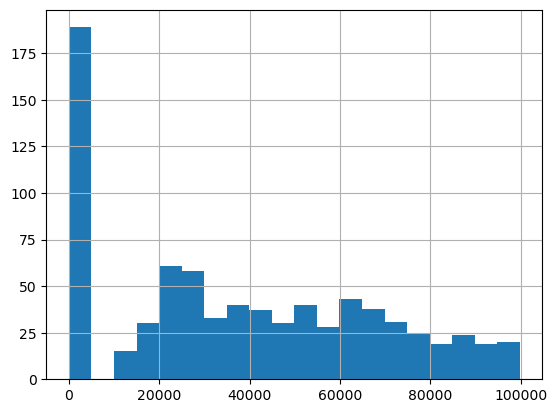

In [57]:
# Personal Auto
df[df["Policy Type"] == "Personal Auto"]["Income"].hist(bins=20)

In [62]:
print(df[df["Policy Type"] == "Personal Auto"]["Income"].mean())

38180.69871794872


<Axes: >

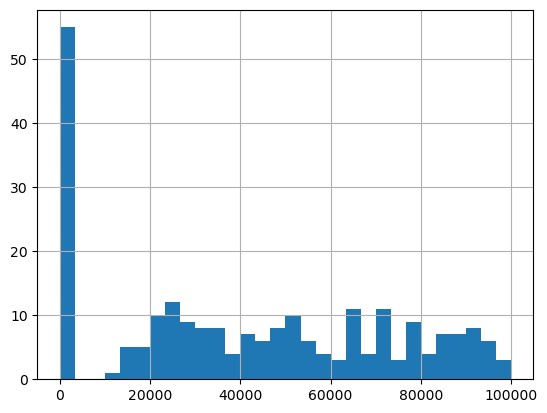

In [65]:
# Corporate Auto
df[df["Policy Type"] == "Corporate Auto"]["Income"].hist(bins=30)

In [67]:
print(df[df["Policy Type"] == "Corporate Auto"]["Income"].mean())

41390.31196581197


### Bonus: Exercise 4


Your goal is to identify customers with a high policy claim amount.

Instructions:

- Review again the statistics for total claim amount to gain an understanding of the data.
- To identify potential areas for improving customer retention and profitability, we want to focus on customers with a high policy claim amount. Consider customers with a high policy claim amount to be those in the top 25% of the total claim amount. Create a pandas DataFrame object that contains information about customers with a policy claim amount greater than the 75th percentile.
- Use DataFrame methods to calculate summary statistics about the high policy claim amount data. 

*Note: When analyzing data, we often want to focus on certain groups of values to gain insights. Percentiles are a useful tool to help us define these groups. A percentile is a measure that tells us what percentage of values in a dataset are below a certain value. For example, the 75th percentile represents the value below which 75% of the data falls. Similarly, the 25th percentile represents the value below which 25% of the data falls. When we talk about the top 25%, we are referring to the values that fall above the 75th percentile, which represent the top quarter of the data. On the other hand, when we talk about the bottom 25%, we are referring to the values that fall below the 25th percentile, which represent the bottom quarter of the data. By focusing on these groups, we can identify patterns and trends that may be useful for making decisions and taking action.*

*Hint: look for a method that gives you the percentile or quantile 0.75 and 0.25 for a Pandas Series.*

*Hint 2: check `Boolean selection according to the values of a single column` in https://towardsdatascience.com/filtering-data-frames-in-pandas-b570b1f834b9*

In [68]:
# Your code here
df["Total Claim Amount"].min()

np.float64(0.382107)

In [69]:
df["Total Claim Amount"].max()

np.float64(2893.239678)

<Axes: >

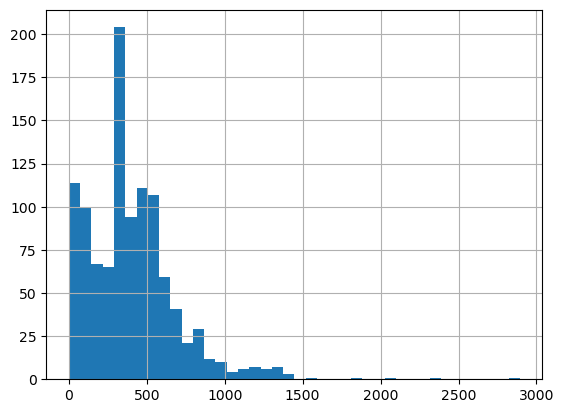

In [71]:
df["Total Claim Amount"].hist(bins=40)

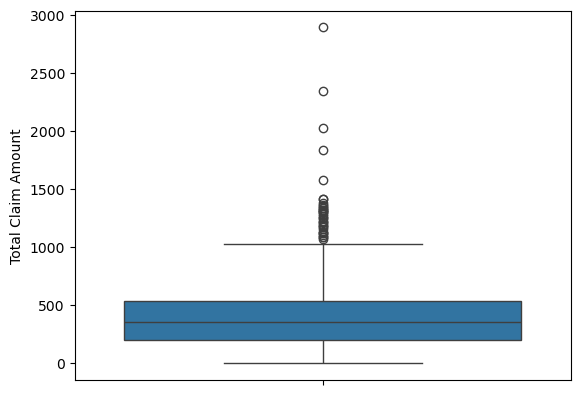

In [72]:
sns.boxplot(df["Total Claim Amount"])
plt.show()

In [77]:
df["Total Claim Amount"].describe()

count    1071.000000
mean      404.986909
std       293.027260
min         0.382107
25%       202.157702
50%       354.729129
75%       532.800000
max      2893.239678
Name: Total Claim Amount, dtype: float64

In [78]:
df[df["Total Claim Amount"] > df["Total Claim Amount"].quantile(0.75)]["Customer"]

1       QZ44356
2       AI49188
17      OE15005
23      TZ98966
26      US89481
         ...   
1059    YG44474
1061    RY92647
1068    GS98873
1069    CW49887
1070    MY31220
Name: Customer, Length: 264, dtype: object